# Disease Prediction with Explainable AI (XAI)
**Stack:** Python · Pandas · Scikit-learn · XGBoost · SHAP · LIME

---
This notebook covers:
1. Exploratory Data Analysis (EDA)
2. Preprocessing
3. Model Training (Random Forest + XGBoost)
4. Evaluation (Accuracy, F1, ROC-AUC)
5. SHAP Explanations (global + local)
6. LIME Explanations (local)


In [9]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap lime

In [10]:
import shap
shap.initjs()

In [11]:
# --- 1. System Settings ---
import warnings
warnings.filterwarnings('ignore')

# --- 2. Data Manipulation & Visualization ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- 3. Third-Party Machine Learning Frameworks ---
import shap
from lime import lime_tabular
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Load Dataset

In [12]:
df = pd.read_csv('heart_disease_uci.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [13]:
print('Class distribution:')
print(df['num'].value_counts())

print(f'\nMissing values: {df.isnull().sum().sum()}')

# Display summary statistics
df.describe()

Class distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Missing values: 1759


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## 2. Exploratory Data Analysis

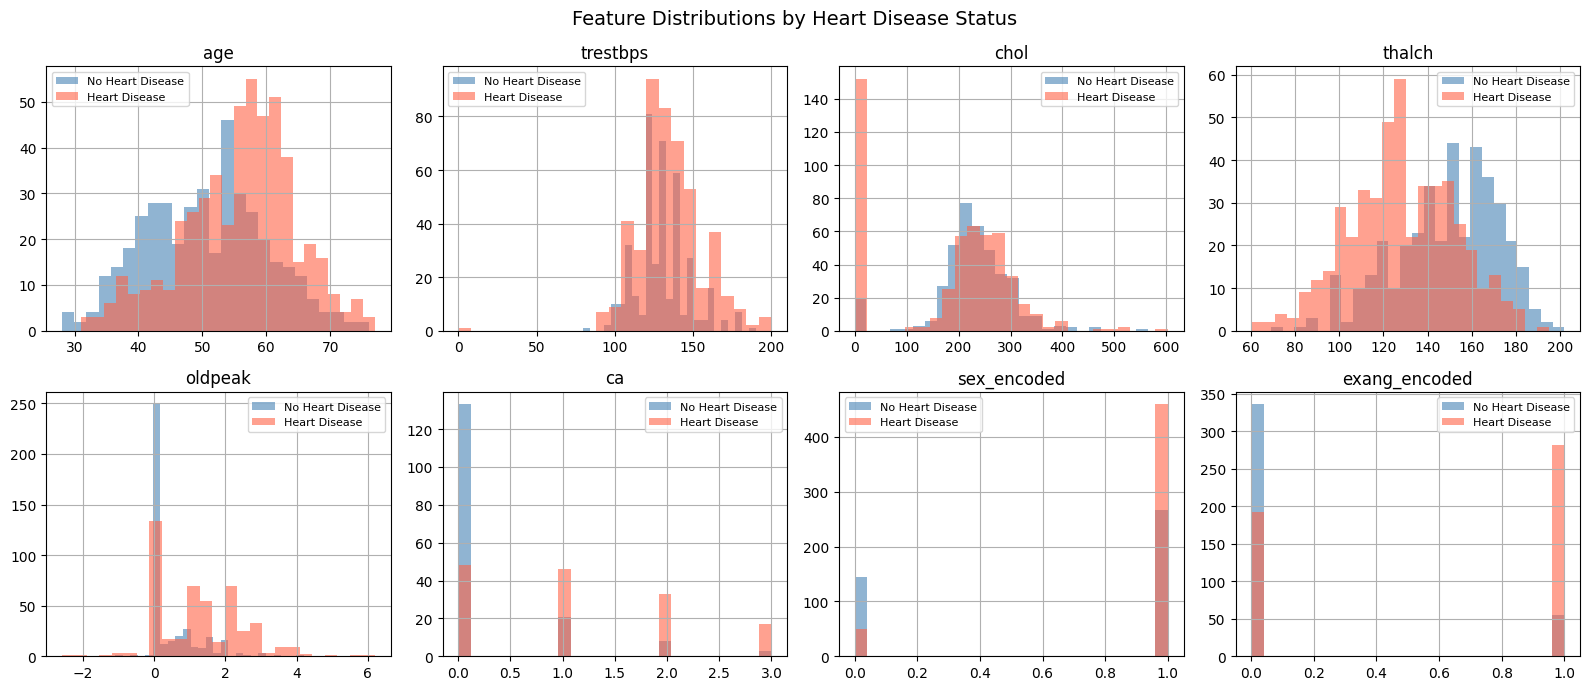

In [14]:
# 1. Create a binary target column (0 = No Heart Disease, 1 = Heart Disease)
df['HeartDisease'] = (df['num'] > 0).astype(int)

# 2. Convert binary categorical features into numeric formats for plotting
df['sex_encoded'] = df['sex'].map({'Male': 1, 'Female': 0})
df['exang_encoded'] = df['exang'].map(
    {True: 1, False: 0, 'True': 1, 'False': 0}
)

# 3. Define exactly 8 features to fit your 2x4 layout
FEATURES = [
    'age',
    'trestbps',
    'chol',
    'thalch',
    'oldpeak',
    'ca',
    'sex_encoded',
    'exang_encoded',
]

# 4. Generate the 2x4 grid plot
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, col in zip(axes.ravel(), FEATURES):
    df[df['HeartDisease'] == 0][col].hist(
        ax=ax, alpha=0.6, label='No Heart Disease', bins=25, color='steelblue'
    )
    df[df['HeartDisease'] == 1][col].hist(
        ax=ax, alpha=0.6, label='Heart Disease', bins=25, color='tomato'
    )
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Heart Disease Status', fontsize=14)
plt.tight_layout()
plt.show()

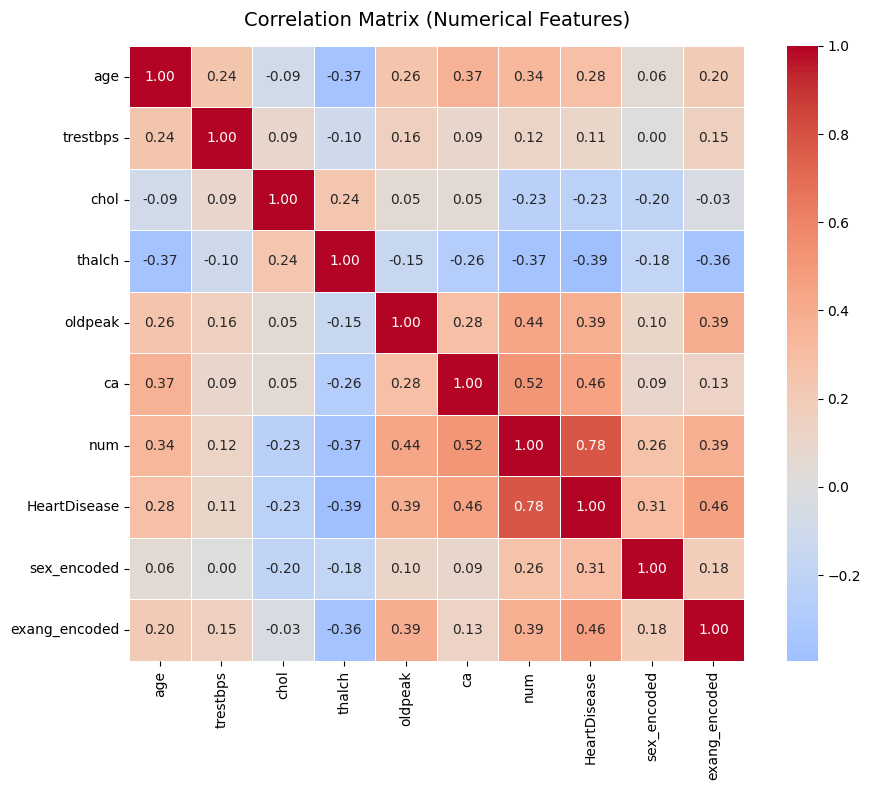

In [15]:
# 1. (Optional) Create a binary target if you are doing binary classification
df['HeartDisease'] = (df['num'] > 0).astype(int)

# 2. Drop the 'id' column since ID correlation is meaningless
df_numeric = df.drop(columns=['id'], errors='ignore')

# 3. Plot the correlation matrix heatmap using numeric_only=True
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_numeric.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title('Correlation Matrix (Numerical Features)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

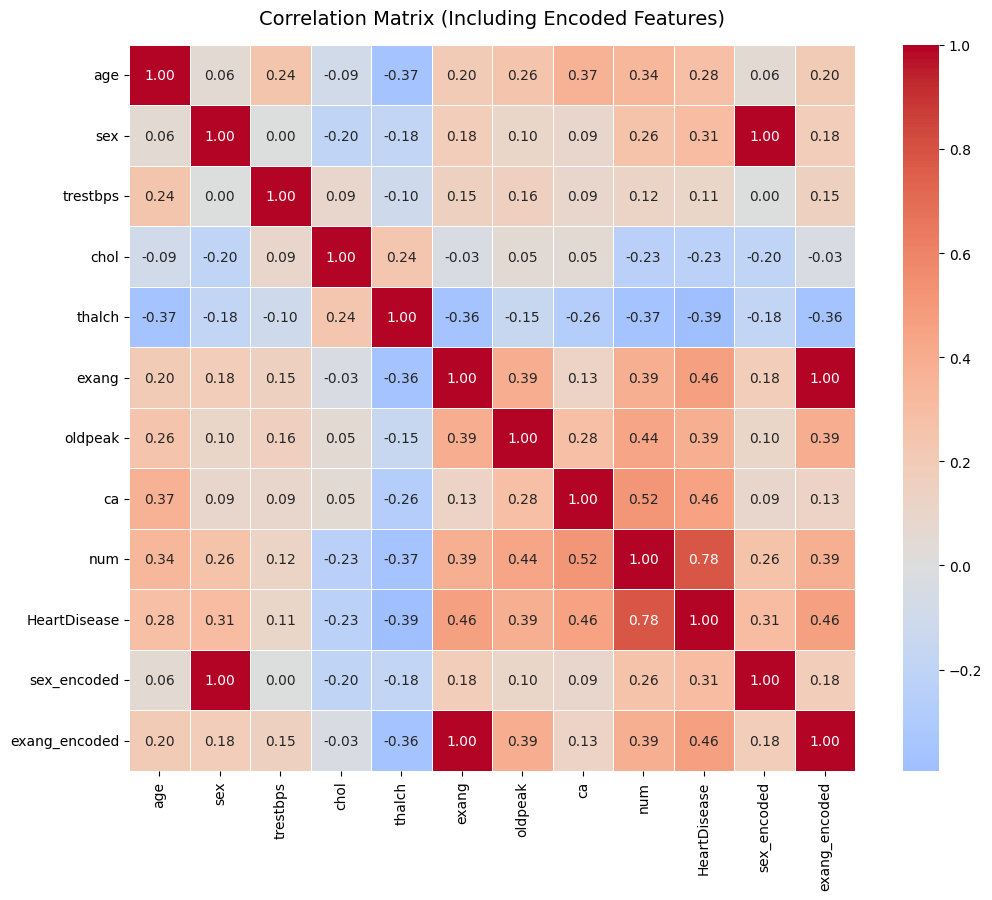

In [16]:
# Create a copy for correlation analysis
df_encoded = df.drop(columns=['id'], errors='ignore').copy()

# Convert binary categories to 1 and 0
df_encoded['sex'] = df_encoded['sex'].map({'Male': 1, 'Female': 0})
df_encoded['exang'] = df_encoded['exang'].map(
    {True: 1, False: 0, 'True': 1, 'False': 0}
)

# Plotting
plt.figure(figsize=(11, 9))
sns.heatmap(
    df_encoded.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title(
    'Correlation Matrix (Including Encoded Features)', fontsize=14, pad=15
)
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [17]:
# 1. Create binary target
df['HeartDisease'] = (df['num'] > 0).astype(int)

# 2. Select features to keep (dropping metadata columns like 'id', 'num', 'dataset')
df_filtered = df.drop(columns=['id', 'num', 'dataset'], errors='ignore')

# 3. Impute missing numeric data with median values
numeric_cols = df_filtered.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    df_filtered[col] = df_filtered[col].fillna(df_filtered[col].median())

# 4. Convert text categories into dummy/one-hot numerical metrics
# This automatically handles categorical NaNs by assigning them 0 across dummy columns
df_encoded = pd.get_dummies(df_filtered, drop_first=True)

# 5. Separate X and y
X = df_encoded.drop(columns=['HeartDisease'])
y = df_encoded['HeartDisease']

# 6. Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Standardize features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}, Test: {X_test_s.shape}')

Train: (736, 20), Test: (184, 20)


## 4. Model Training

In [18]:
# --- 1. Random Forest Classifier ---
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train_s, y_train)

# --- 2. XGBoost Classifier ---
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    eval_metric='logloss',  # Optimal loss metric for binary classification
    # & with "mlogloss" for multi-class prediction (0,1,2,3...n) severity levels
    random_state=42,
)
xgb.fit(X_train_s, y_train)

print('Models trained ✅')

Models trained ✅


## 5. Evaluation

In [19]:
from sklearn.metrics import classification_report, roc_auc_score

for name, model in [('Random Forest', rf), ('XGBoost', xgb)]:
    print(f'\n{"─" * 10} {name} {"─" * 10}')

    # Calculate predictions and metrics
    accuracy = model.score(X_test_s, y_test)
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f'Accuracy : {accuracy:.4f}')
    print(f'ROC-AUC  : {roc_auc:.4f}\n')

    # Updated target names matching the Heart Disease dataset
    print(classification_report(
        y_test,
        y_pred,
        target_names=['No Heart Disease', 'Heart Disease']
    ))


────────── Random Forest ──────────
Accuracy : 0.8315
ROC-AUC  : 0.9130

                  precision    recall  f1-score   support

No Heart Disease       0.83      0.78      0.81        82
   Heart Disease       0.83      0.87      0.85       102

        accuracy                           0.83       184
       macro avg       0.83      0.83      0.83       184
    weighted avg       0.83      0.83      0.83       184


────────── XGBoost ──────────
Accuracy : 0.8424
ROC-AUC  : 0.9002

                  precision    recall  f1-score   support

No Heart Disease       0.85      0.78      0.82        82
   Heart Disease       0.83      0.89      0.86       102

        accuracy                           0.84       184
       macro avg       0.84      0.84      0.84       184
    weighted avg       0.84      0.84      0.84       184



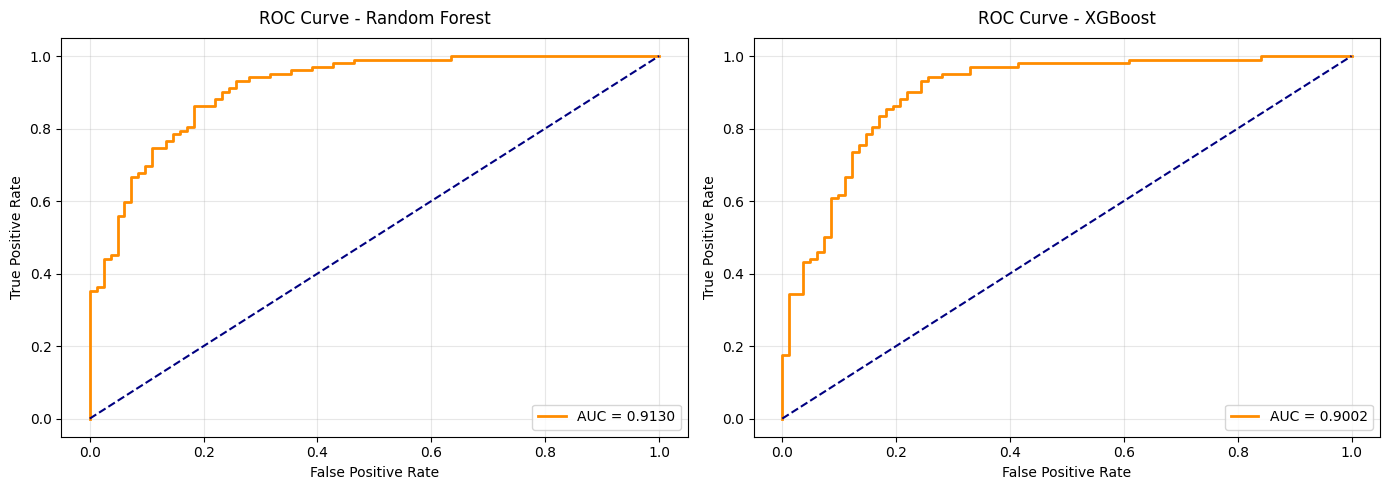

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# Create a side-by-side subplot grid (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, [('Random Forest', rf), ('XGBoost', xgb)]):
    # Calculate probabilities once per model
    y_proba = model.predict_proba(X_test_s)[:, 1]

    # Compute ROC curve and AUC score
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    # Plotting the ROC curve
    ax.plot(fpr, tpr, lw=2, label=f'AUC = {auc:.4f}', color='darkorange')
    ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')

    # Labels and aesthetics
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'ROC Curve - {name}', fontsize=12, pad=10)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. SHAP — Global Feature Importance

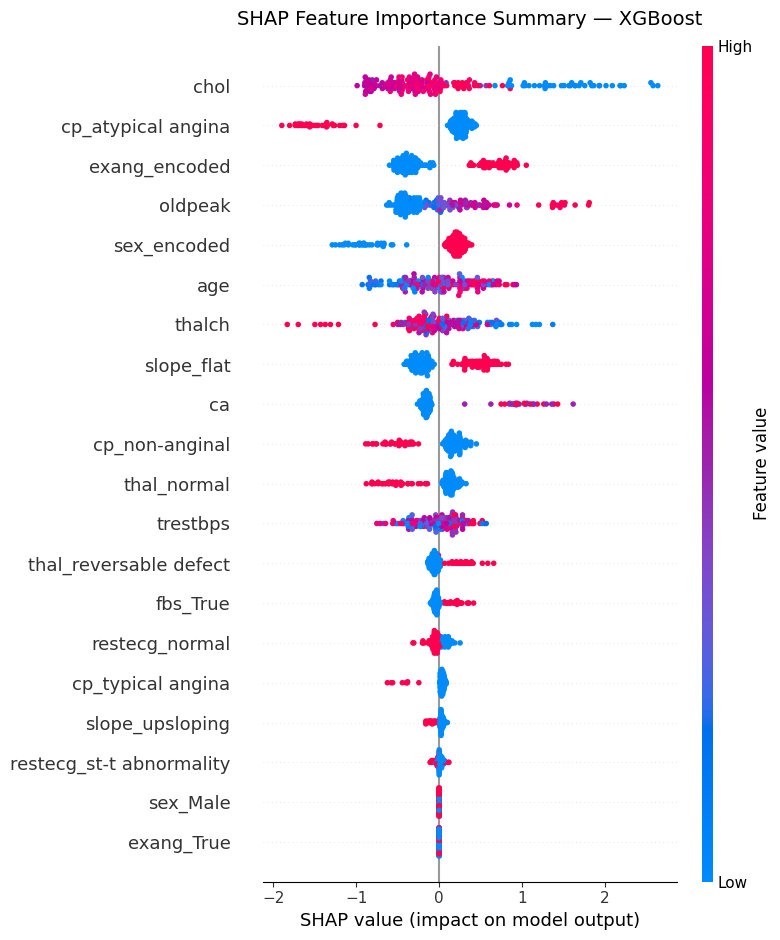

In [21]:
# 1. Initialize the SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb)

# 2. Compute SHAP values using the scaled test features
shap_values = explainer.shap_values(X_test_s)

# 3. Handle formatting safety check (list vs array)
# Binary XGBoost usually outputs a single matrix, while Random Forest outputs a list
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# 4. Create the plot
plt.figure(figsize=(10, 6))

# Pass X_test directly so SHAP can color the dots using original feature values
# and automatically pull the feature names from the DataFrame columns!
shap.summary_plot(
    sv,
    X_test,
    show=False
)

# Customize title and display aesthetics
plt.title('SHAP Feature Importance Summary — XGBoost', fontsize=14, pad=15)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 7. SHAP — Local Explanation (Single Patient)

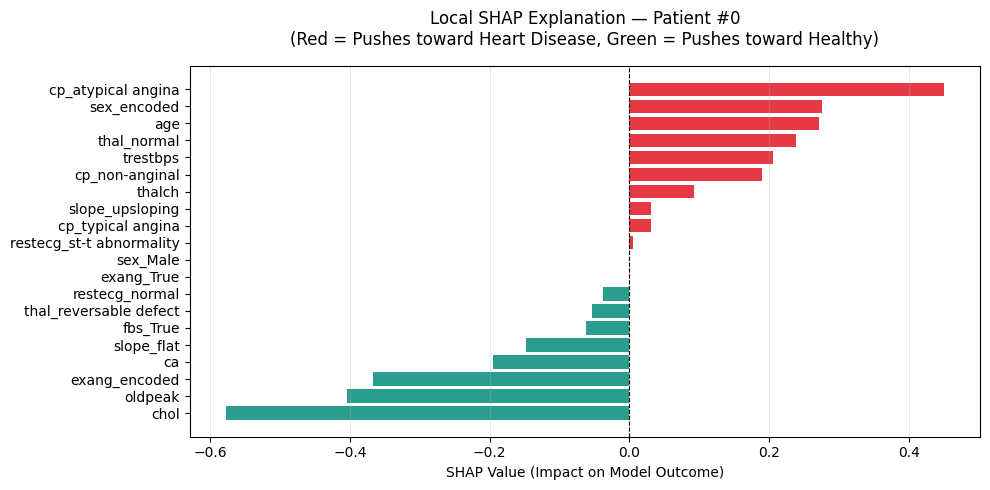

Prediction  : Heart Disease
Probability : 0.5387


In [22]:
# 1. Select the specific patient index
patient_idx = 0
patient = X_test_s[patient_idx : patient_idx + 1]

# 2. Extract SHAP values for this single patient
sv_patient = explainer.shap_values(patient)
sv_show = sv_patient[1][0] if isinstance(sv_patient, list) else sv_patient[0]

# 3. Dynamically get feature names from the dataset to ensure perfect alignment
feature_names = (
    X_test.columns if isinstance(X_test, pd.DataFrame) else FEATURES
)

# 4. Create a DataFrame to sort features by their impact (magnitude of SHAP value)
df_shap = pd.DataFrame({'Feature': feature_names, 'SHAP_Value': sv_show})
df_shap['Abs_SHAP'] = df_shap['SHAP_Value'].abs()
df_shap = df_shap.sort_values(by='SHAP_Value', ascending=True)  # Sort the bars

# 5. Define colors based on the contribution direction
colors = ['#e63946' if v > 0 else '#2a9d8f' for v in df_shap['SHAP_Value']]

# 6. Plotting
plt.figure(figsize=(10, 5))
plt.barh(df_shap['Feature'], df_shap['SHAP_Value'], color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')

# Labels and aesthetics
plt.xlabel('SHAP Value (Impact on Model Outcome)', fontsize=10)
plt.title(
    f'Local SHAP Explanation — Patient #{patient_idx}\n(Red = Pushes toward Heart Disease, Green = Pushes toward Healthy)',
    fontsize=12,
    pad=15,
)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Print the updated diagnosis prediction and probability
pred_class = xgb.predict(patient)[0]
pred_prob = xgb.predict_proba(patient)[0][1]

print(
    f'Prediction  : {"Heart Disease" if pred_class == 1 else "No Heart Disease"}'
)
print(f'Probability : {pred_prob:.4f}')

## 8. LIME — Local Explanation

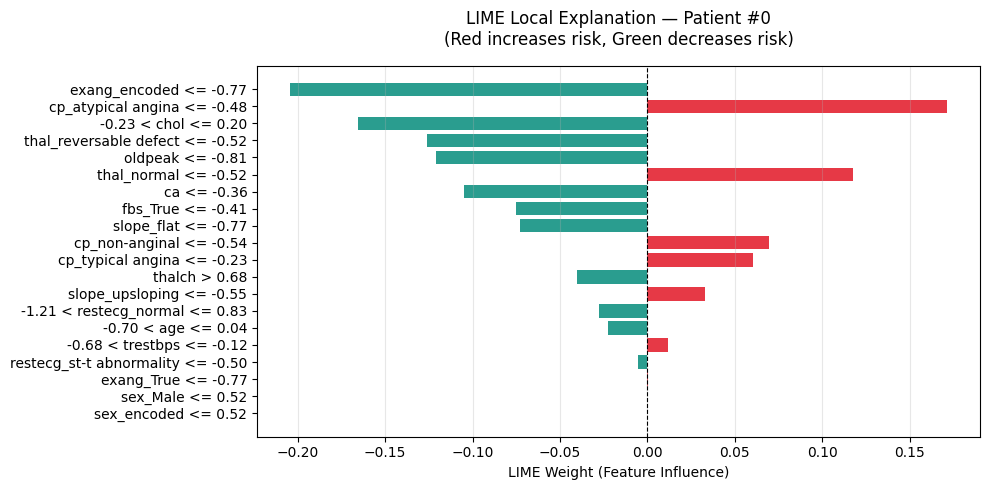

In [23]:
import matplotlib.pyplot as plt
from lime import lime_tabular

# 1. Dynamically retrieve feature names from your processed DataFrame
feature_names_lime = (
    list(X_train.columns) if hasattr(X_train, 'columns') else FEATURES
)

# 2. Initialize the LIME Explainer with updated heart disease classes
lime_explainer = lime_tabular.LimeTabularExplainer(
    X_train_s,
    feature_names=feature_names_lime,
    class_names=['No Heart Disease', 'Heart Disease'],
    mode='classification',
    random_state=42,
)

# 3. Generate the local explanation for your selected patient
# Setting num_features dynamically handles both simple and dummy-encoded sets
exp = lime_explainer.explain_instance(
    X_test_s[patient_idx],
    xgb.predict_proba,
    num_features=len(feature_names_lime),
)

# 4. Extract weights and rules
lime_list = exp.as_list()
features_l = [x[0] for x in lime_list]
weights_l = [x[1] for x in lime_list]

# 5. Define directional coloring (Red = Risk, Green = Protective)
colors_l = ['#e63946' if w > 0 else '#2a9d8f' for w in weights_l]

# 6. Build the visualization
plt.figure(figsize=(10, 5))
plt.barh(features_l, weights_l, color=colors_l)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')

# Aesthetics and formatting
plt.xlabel('LIME Weight (Feature Influence)', fontsize=10)
plt.title(
    f'LIME Local Explanation — Patient #{patient_idx}\n(Red increases risk, Green decreases risk)',
    fontsize=12,
    pad=15,
)
plt.gca().invert_yaxis()  # Keeps the most important features at the top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 9. **Hyperparameter Tuning (Optimize Performance)**
Using manual/**default** parameters for models (e.g., max_depth=5 for XGBoost). The standard next step is to use GridSearchCV or RandomizedSearchCV to systematically test hundreds of parameter combinations to find the absolute best settings.

In [24]:
from sklearn.model_selection import GridSearchCV

# Define a grid of parameters to test
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.8, 0.9]
}

# Initialize Grid Search with 5-fold Cross-Validation
grid_search = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit to training data
grid_search.fit(X_train_s, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Update your xgb model with the best estimator
best_xgb = grid_search.best_estimator_

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}
Best CV ROC-AUC: 0.8875


# 10. Final comparison:
To compile all evaluation parameters—Accuracy, Precision, Recall, F1-Score, and ROC-AUC—into a single, consolidated view for easy comparison, you can use the following unified code block.

In [25]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

# Create an empty list to store the metrics
metrics_list = []

# Loop through both models to gather all data points
for name, model in [('Random Forest', rf), ('XGBoost', xgb)]:
    # 1. Get predictions and probabilities
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]

    # 2. Calculate global metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    # 3. Calculate per-class metrics (Precision, Recall, F1-score)
    # precision[0]=Healthy, precision[1]=Heart Disease
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

    # 4. Save everything in a dictionary for this model
    metrics_list.append({
        'Model': name,
        'Overall Accuracy': f"{accuracy:.4f}",
        'Overall ROC-AUC': f"{roc_auc:.4f}",
        'Class 0 (Healthy) Precision': f"{precision[0]:.4f}",
        'Class 0 (Healthy) Recall': f"{recall[0]:.4f}",
        'Class 0 (Healthy) F1-Score': f"{f1[0]:.4f}",
        'Class 1 (Disease) Precision': f"{precision[1]:.4f}",
        'Class 1 (Disease) Recall': f"{recall[1]:.4f}",
        'Class 1 (Disease) F1-Score': f"{f1[1]:.4f}"
    })

# Convert the consolidated metrics list into a clean single DataFrame
df_comparison = pd.DataFrame(metrics_list).set_index('Model').T

print("======== ALL EVALUATION PARAMETERS ========")
display(df_comparison)

======== ALL EVALUATION PARAMETERS ========


Model,Random Forest,XGBoost
Overall Accuracy,0.8315,0.8424
Overall ROC-AUC,0.9130,0.9002
Class 0 (Healthy) Precision,0.8312,0.8533
Class 0 (Healthy) Recall,0.7805,0.7805
Class 0 (Healthy) F1-Score,0.8050,0.8153
Class 1 (Disease) Precision,0.8318,0.8349
Class 1 (Disease) Recall,0.8725,0.8922
Class 1 (Disease) F1-Score,0.8517,0.8626


In [31]:
import joblib

# This dumps the final objects so app.py can read them
joblib.dump(xgb, 'best_xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Saved! Check your sidebar folder for the .pkl files.")

Saved! Check your sidebar folder for the .pkl files.
